# Proyecto I - Parte final

## Parte 1: Exploración y Visualización de Datos (EDA)

1. Carga y Exploración Inicial de Datos:
*   Cargar el dataset y revisar su estructura básica.
*   Describir las variables y su distribución.
*   Identificar y tratar valores nulos y outliers.
2. Análisis de Correlación:
*   Realizar un análisis de correlación y crear un mapa de calor para visualizar las relaciones entre las variables.
3. Visualización de Datos:
*   Crear subplots para comparar diferentes variables clave.
*   Añadir cuadrículas, leyendas, anotaciones y flechas a los gráficos para mejorar la claridad y la información.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


Tenemos un dataset de 1000 datos, correspondientes a ventas. Se observa de inmediato que la columna 'Date' debería ser de tipo datatime, siendo esta la única inconcordancia.

In [30]:
df['Date']= pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


Vemos que no hay valores nulos. Vamos a identificar y eliminar duplicados

In [31]:
df=df.drop_duplicates()
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


A simple vista no se detectan valores outliers, pero verificaremos.

In [32]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return len(outliers)

columns = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']

print("\nOutliers por Característica:")
for column in columns:
    print(f"{column}: {detect_outliers(df, column)} outliers")




Outliers por Característica:
Age: 0 outliers
Quantity: 0 outliers
Price per Unit: 0 outliers
Total Amount: 0 outliers


Analizaremos ahora las correlaciones

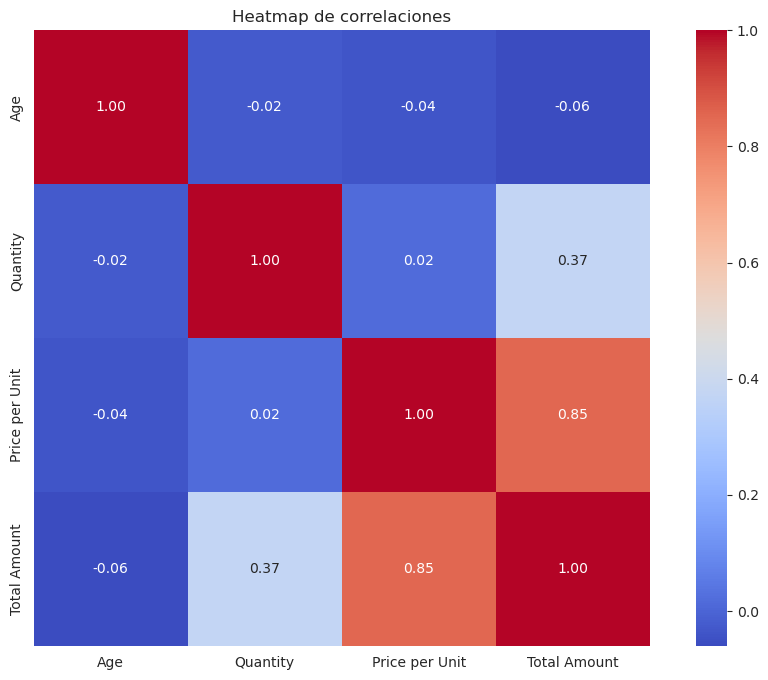

In [33]:
data=df[columns]
df_corr = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Heatmap de correlaciones')
plt.show()

Obviamente, la cantidad total se relaciona con el precio por unidad. Más allá de eso no se observan correlaciones muy apreciables.

Analizaremos ahora los datos utilizando visualizaciones. Vamos a eliminar la columna 'Total amount', ya que es obviamente obtenible de las otras dos

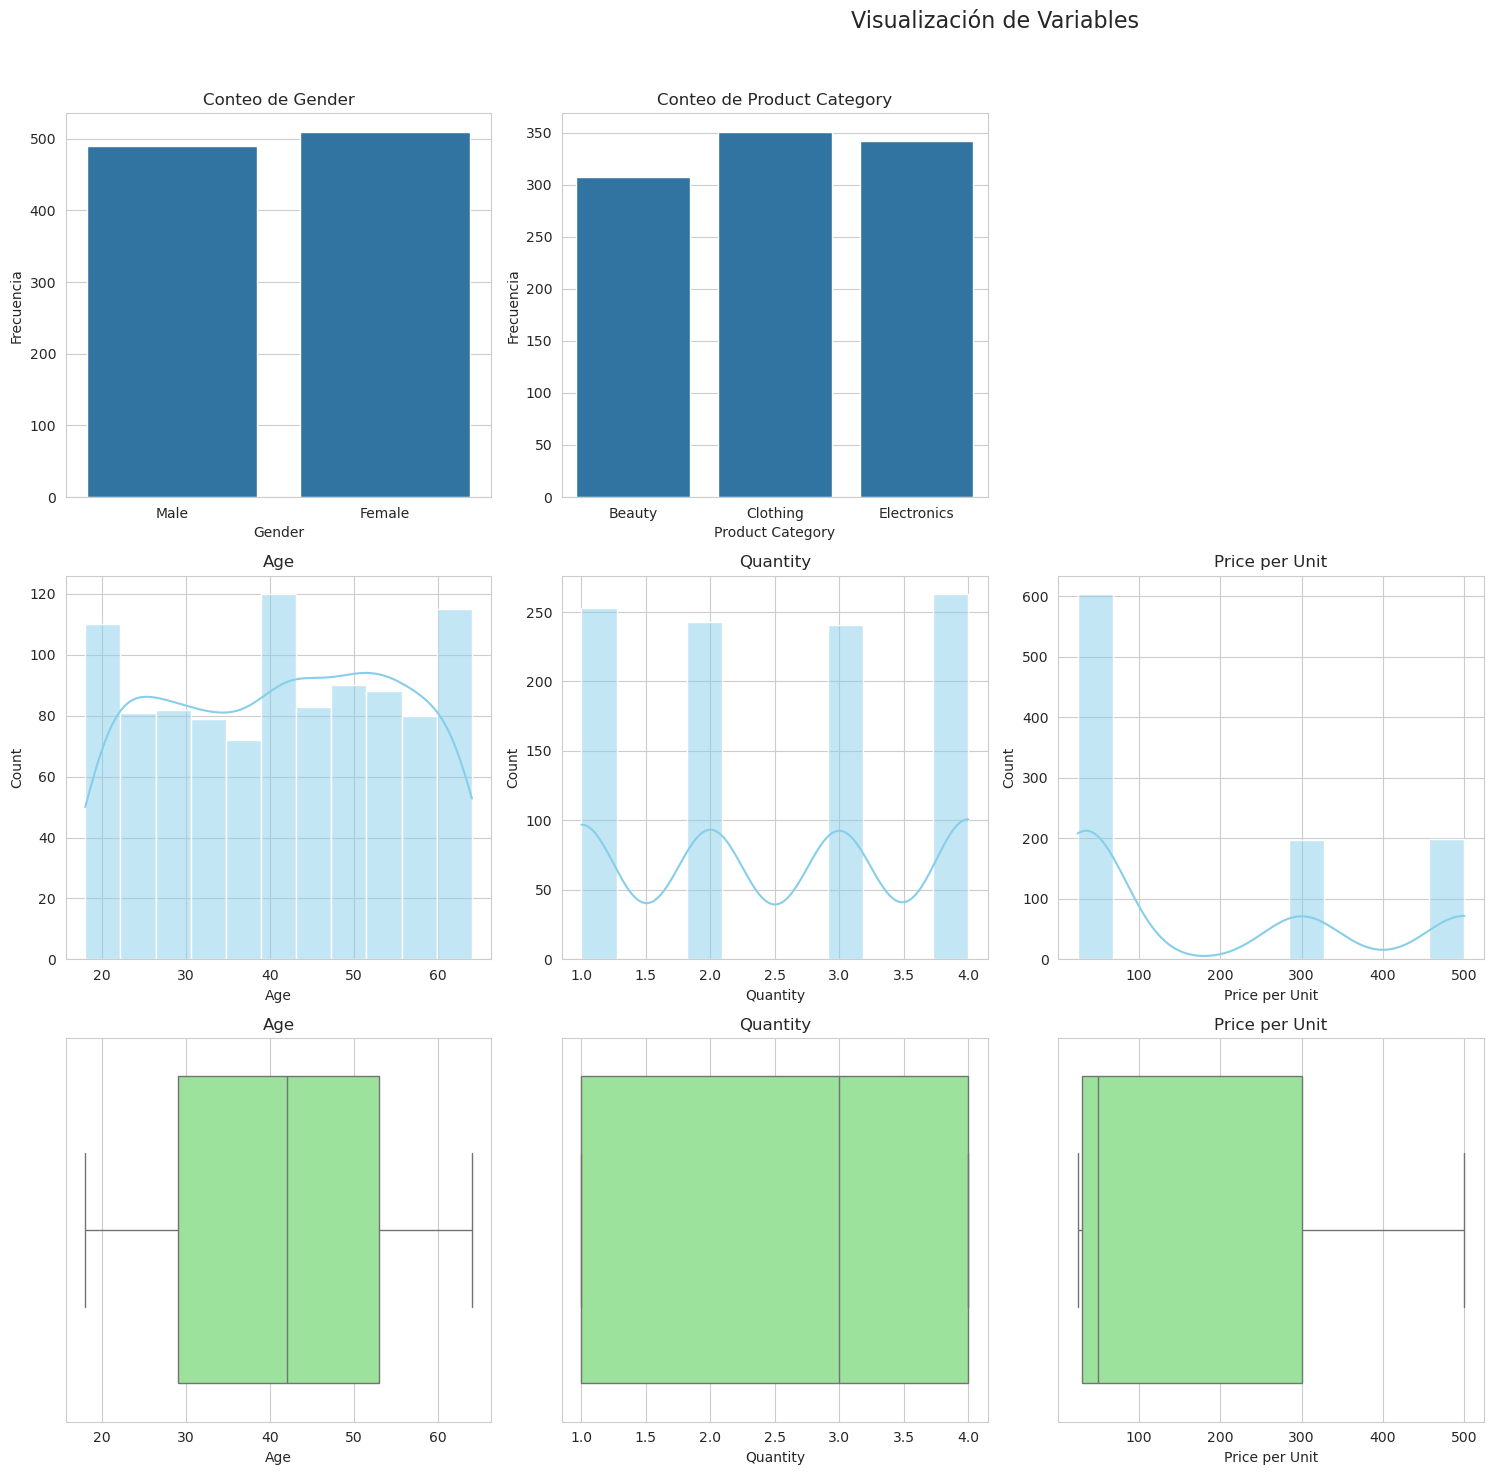

In [35]:
cat_cols = ['Gender', 'Product Category']
num_cols = ['Age', 'Quantity', 'Price per Unit']

fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(20, 15))
fig.suptitle('Visualización de Variables', fontsize=16)


for i, col in enumerate(cat_cols):
    ax = axes[0, i]
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f'Conteo de {col}')
    ax.set_ylabel('Frecuencia')
    ax.set_xlabel(col)

# Eliminar ejes vacíos restantes de la fila 0 (si hay menos de 4 variables categóricas)
for j in range(len(cat_cols), 4):
    fig.delaxes(axes[0, j])

#gráficos para variables numéricas
for i, col in enumerate(num_cols):
    # Histograma en la fila 1
    ax_hist = axes[1, i]
    sns.histplot(df[col], kde=True, ax=ax_hist, color='skyblue')
    ax_hist.set_title(col)
    ax_hist.set_xlabel(col)

    # Boxplot en la fila 2
    ax_box = axes[2, i]
    sns.boxplot(x=df[col], ax=ax_box, color='lightgreen')
    ax_box.set_title(col)
    ax_box.set_xlabel(col)

# Eliminar ejes vacíos restantes en filas 1 y 2 (si hay menos de 4 numéricas)
for j in range(len(num_cols), 4):
    fig.delaxes(axes[1, j])
    fig.delaxes(axes[2, j])

# Ajustar espacios entre subplots
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Vamos a centrar nuestro análisis en intentar predecir el género de un comprador, a partir de las variablles. Para 'date', vamos a utilizar solo el mes. Antes, verificaremos la lista de valores de las variables

In [36]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # coerce convierte errores en NaT
df['Mes'] = df['Date'].dt.month
columnas= ['Mes', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']
df = df[columnas]
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Mes               1000 non-null   int32 
 1   Gender            1000 non-null   object
 2   Age               1000 non-null   int64 
 3   Product Category  1000 non-null   object
 4   Quantity          1000 non-null   int64 
 5   Price per Unit    1000 non-null   int64 
 6   Total Amount      1000 non-null   int64 
dtypes: int32(1), int64(4), object(2)
memory usage: 50.9+ KB


In [37]:
for col in df.columns:
    print(f"Valores únicos en {col}: {df[col].nunique()}")

Valores únicos en Mes: 12
Valores únicos en Gender: 2
Valores únicos en Age: 47
Valores únicos en Product Category: 3
Valores únicos en Quantity: 4
Valores únicos en Price per Unit: 5
Valores únicos en Total Amount: 18


Estos valores no presentan mayores sorpresas, y salvo en 'age' presentan poca variabilidad, lo que ayudará a un modelamiento más efectivo.

Crearemos nuevas visualizaciones, separando por género.

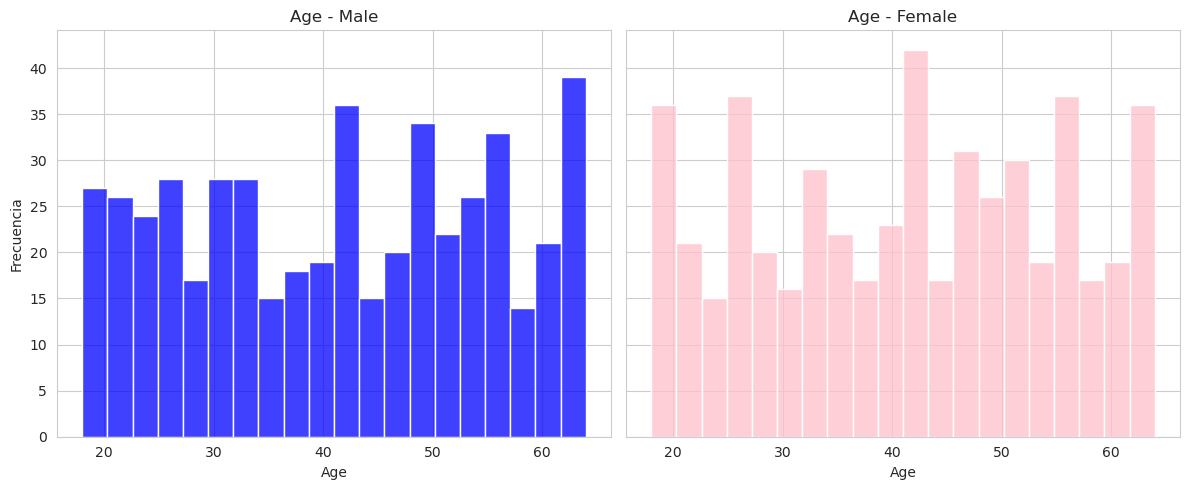

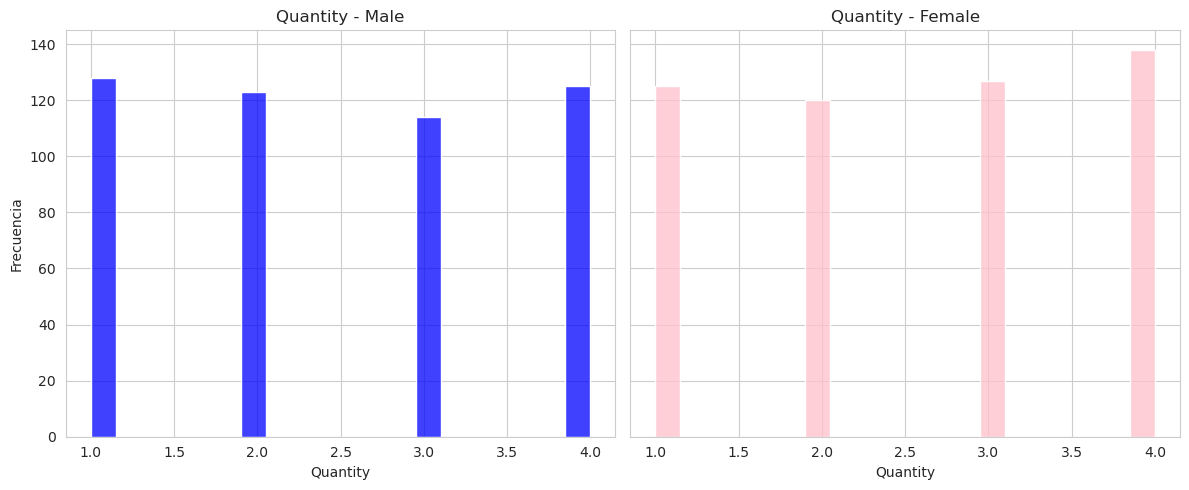

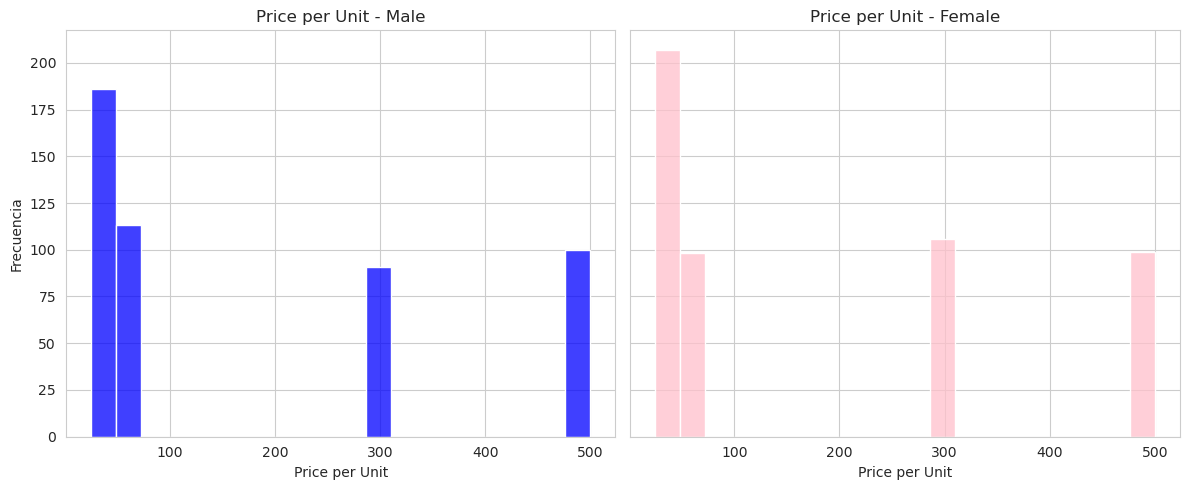

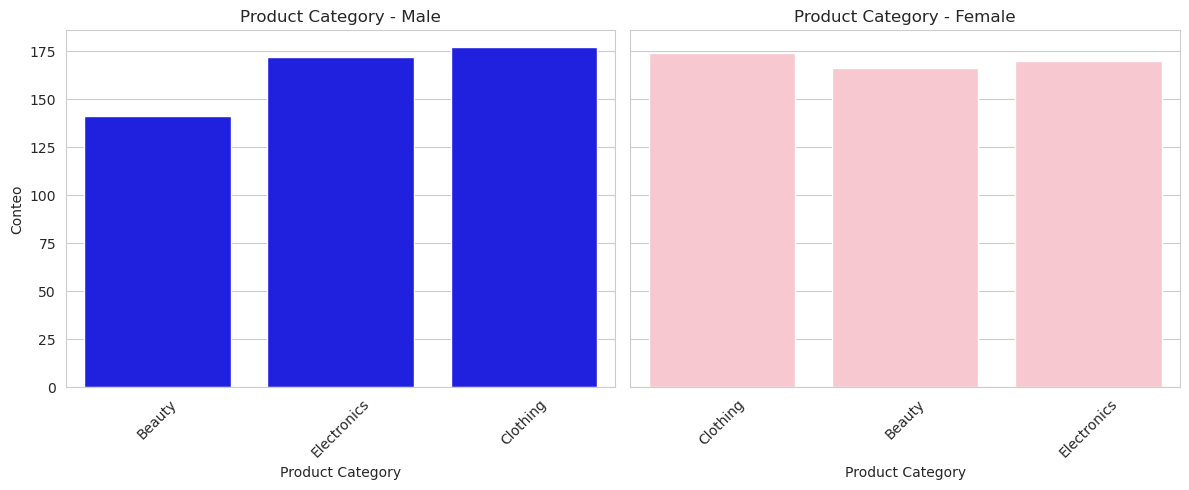

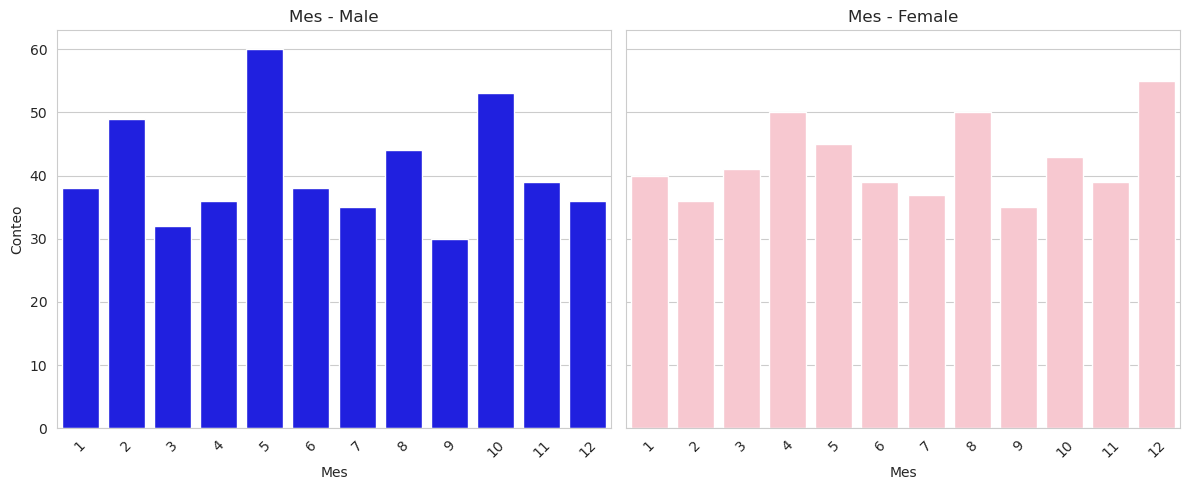

In [39]:
# Separamos el DataFrame por género
df_male = df[df['Gender'] == 'Male']
df_female = df[df['Gender'] == 'Female']

numerical_columns = ['Age', 'Quantity', 'Price per Unit']

for col in numerical_columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    
    #Male
    sns.histplot(data=df_male, x=col, bins=20, ax=axes[0], color='blue')
    axes[0].set_title(f'{col} - Male')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')
    
    #Female
    sns.histplot(data=df_female, x=col, bins=20, ax=axes[1], color='pink')
    axes[1].set_title(f'{col} - Female')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Frecuencia')
    
    plt.tight_layout()
    plt.show()

categorical_columns = ['Product Category', 'Mes']

for col in categorical_columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    
    # Male
    sns.countplot(data=df_male, x=col, ax=axes[0], color='blue')
    axes[0].set_title(f'{col} - Male')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Conteo')
    axes[0].tick_params(axis='x', rotation=45)
    
    #Female
    sns.countplot(data=df_female, x=col, ax=axes[1], color='pink')
    axes[1].set_title(f'{col} - Female')
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Conteo')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

Vemos que la distribución entre géneros no es demasiado distinta, lo que augura un mal resultado predictivo...